# Просмотр датасета

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, mean_shift
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

## Загрузка данных и первичный обзор

In [3]:
df = pd.read_csv('../../data/raw/dataset.csv')
df = df.drop('Unnamed: 0', axis=1)
df = df.drop('Индексы_производства_продукции_СХ_%', axis=1)
df.head()

,Регион,Год,Объем_сточных_вод_млн_м3,Инвестиции_в_ООС_тыс_руб,ВРП_млн_руб,ВРП_на_душу_руб,Доля_городского_населения_%,Использование_свеж_воды_млн_м3,Индекс_промыш_производства_%
0,Алтайский край,2000,31.0,176660.0,46736.8,17660.5,52.8,569.0,109.2
1,Алтайский край,2001,34.0,111590.0,61854.4,23509.0,53.1,599.0,109.4
2,Алтайский край,2002,36.0,67466.0,73107.4,27991.2,53.2,563.0,100.1
3,Алтайский край,2003,36.0,50114.0,88733.3,34295.8,53.5,516.0,105.5
4,Алтайский край,2004,36.0,38270.0,114840.5,44934.9,53.7,488.0,102.6


### Анализ пропусков и структуры данных

In [4]:
df.isna().sum()

Регион                             0
Год                                0
Объем_сточных_вод_млн_м3           5
Инвестиции_в_ООС_тыс_руб           5
ВРП_млн_руб                        5
ВРП_на_душу_руб                   36
Доля_городского_населения_%        0
Использование_свеж_воды_млн_м3     0
Индекс_промыш_производства_%      21
dtype: int64

In [5]:
df.shape

(1992, 9)

In [6]:
missing_rows = df[df.isnull().any(axis=1)]
missing_rows.head(50)

,Регион,Год,Объем_сточных_вод_млн_м3,Инвестиции_в_ООС_тыс_руб,ВРП_млн_руб,ВРП_на_душу_руб,Доля_городского_населения_%,Использование_свеж_воды_млн_м3,Индекс_промыш_производства_%
48,Архангельская область,2000,540.00,1733357.80,49882.9,NaN,75.3,832.00,NaN
49,Архангельская область,2001,537.00,1874413.00,55391.2,NaN,75.6,828.00,NaN
50,Архангельская область,2002,513.00,1626869.00,66678.0,NaN,75.3,755.00,NaN
51,Архангельская область,2003,477.00,531838.00,78910.7,NaN,75.0,713.00,NaN
52,Архангельская область,2004,454.00,891153.00,102978.0,NaN,75.5,681.00,NaN
53,Архангельская область,2005,464.00,3766789.90,121715.1,NaN,74.0,673.00,NaN
54,Архангельская область,2006,464.00,9456773.00,148684.3,NaN,74.4,670.00,NaN
55,Архангельская область,2007,475.00,1890048.00,170833.8,NaN,74.8,682.00,110.10
56,Архангельская область,2008,475.00,2801967.00,198279.5,NaN,75.1,654.00,102.20
57,Архангельская область,2009,413.00,1699949.20,193429.1,NaN,75.5,609.00,95.50


In [7]:
df.columns

Index(['Регион', 'Год', 'Объем_сточных_вод_млн_м3', 'Инвестиции_в_ООС_тыс_руб',
       'ВРП_млн_руб', 'ВРП_на_душу_руб', 'Доля_городского_населения_%',
       'Использование_свеж_воды_млн_м3', 'Индекс_промыш_производства_%'],
      dtype='object')

In [8]:
df['Регион'].unique()

array(['Алтайский край', 'Амурская область', 'Архангельская область',
       'Астраханская область', 'Белгородская область', 'Брянская область',
       'Владимирская область', 'Волгоградская область',
       'Вологодская область', 'Воронежская область',
       'Еврейская автономная область', 'Забайкальский край',
       'Ивановская область', 'Иркутская область',
       'Кабардино-Балкарская Республика', 'Калининградская область',
       'Калужская область', 'Камчатский край',
       'Карачаево-Черкесская Республика', 'Кемеровская область — Кузбасс',
       'Кировская область', 'Костромская область', 'Краснодарский край',
       'Красноярский край', 'Курганская область', 'Курская область',
       'Ленинградская область', 'Липецкая область', 'Магаданская область',
       'Московская область', 'Мурманская область',
       'Ненецкий автономный округ', 'Нижегородская область',
       'Новгородская область', 'Новосибирская область', 'Омская область',
       'Оренбургская область', 'Орловская

# Подготовка данных для кластеризации 

Для агрегирования признаков по годам нахожу СРЕДНЕЕ за весь период (2000-2023) по конкретному региону

In [9]:
agg_features = {
    'Объем_сточных_вод_млн_м3':'mean',
    'Инвестиции_в_ООС_тыс_руб':'mean',
    'ВРП_млн_руб':'mean',
    'ВРП_на_душу_руб':'mean',
    # 'Индексы_производства_продукции_СХ_%':'mean',
    'Доля_городского_населения_%':'mean',
    'Использование_свеж_воды_млн_м3':'mean',
    'Индекс_промыш_производства_%':'mean'
}
agg_df = df.groupby('Регион').agg(agg_features).reset_index()
pd.set_option('display.max_rows', 10)
agg_df.head()

,Регион,Объем_сточных_вод_млн_м3,Инвестиции_в_ООС_тыс_руб,ВРП_млн_руб,ВРП_на_душу_руб,Доля_городского_населения_%,Использование_свеж_воды_млн_м3,Индекс_промыш_производства_%
0,Алтайский край,21.127500,5.399271e+05,399415.922679,174954.495833,55.545833,431.719167,103.995833
1,Амурская область,78.603333,2.007445e+06,244597.249296,308259.787500,67.120833,93.221250,103.116667
2,Архангельская область,392.086667,3.913759e+06,325785.710663,475677.907692,76.245833,626.489583,101.717647
3,Астраханская область,60.526667,2.921741e+06,287173.118208,291875.175000,66.229167,857.939167,107.087500
4,Белгородская область,46.700417,3.671759e+06,556404.789171,361903.037500,65.683333,270.269167,107.091667


### Создание прокси признаков

In [10]:
# Заменил абсолютные величины, заменяю их на более относительные признаки 
agg_df['Водоемкость_ВРП'] = agg_df['Объем_сточных_вод_млн_м3']/agg_df['ВРП_млн_руб']
agg_df['Инвестиционная_активность'] = agg_df['Инвестиции_в_ООС_тыс_руб']/agg_df['ВРП_млн_руб']


Выделяю признаки, по которым будем класторизовать

In [11]:
features_clustering = [
    'ВРП_на_душу_руб','Объем_сточных_вод_млн_м3',
    'Доля_городского_населения_%',
    'Индекс_промыш_производства_%', 'Водоемкость_ВРП', 'Инвестиционная_активность'
]
clust_df = agg_df[features_clustering]
clust_df.head()

,ВРП_на_душу_руб,Объем_сточных_вод_млн_м3,Доля_городского_населения_%,Индекс_промыш_производства_%,Водоемкость_ВРП,Инвестиционная_активность
0,174954.495833,21.127500,55.545833,103.995833,0.000053,1.351792
1,308259.787500,78.603333,67.120833,103.116667,0.000321,8.207146
2,475677.907692,392.086667,76.245833,101.717647,0.001204,12.013292
3,291875.175000,60.526667,66.229167,107.087500,0.000211,10.174146
4,361903.037500,46.700417,65.683333,107.091667,0.000084,6.599078


### Предобработка данных

In [12]:
scaler = StandardScaler()
clust_scaled = scaler.fit_transform(clust_df)

clust_scaled_df = pd.DataFrame(clust_scaled, columns = clust_df.columns, index = agg_df['Регион'])
clust_scaled_df.head()

,ВРП_на_душу_руб,Объем_сточных_вод_млн_м3,Доля_городского_населения_%,Индекс_промыш_производства_%,Водоемкость_ВРП,Инвестиционная_активность
Регион,,,,,,
Алтайский край,-0.383948,-0.671890,-1.096892,-0.405983,-1.275576,-1.027346
Амурская область,-0.186927,-0.439936,-0.202353,-0.750405,-0.093025,0.117504
Архангельская область,0.060512,0.825186,0.502845,-1.298485,3.792774,0.753134
Астраханская область,-0.211143,-0.512887,-0.271263,0.805208,-0.580168,0.445995
Белгородская область,-0.107644,-0.568686,-0.313446,0.806841,-1.138863,-0.151045


# Кластеризация

Text(0.5, 1.0, 'Метод локтя')

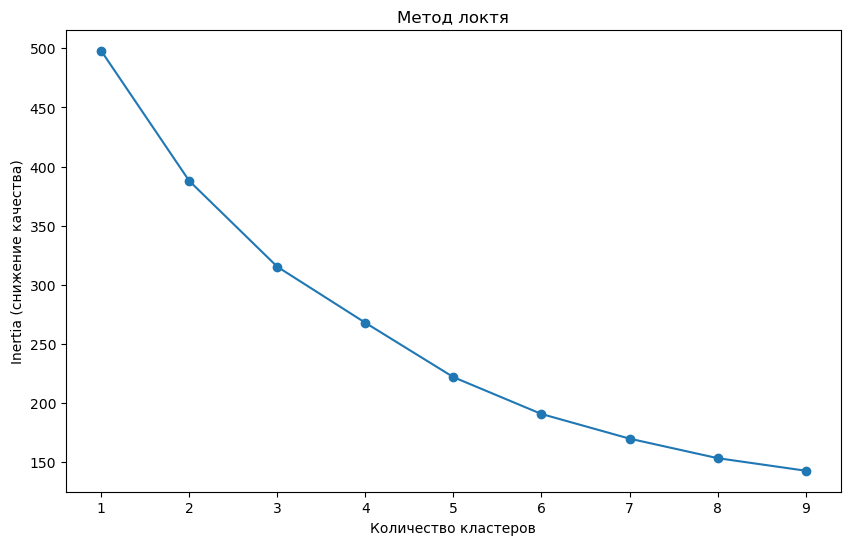

In [13]:
inertia = []
k_range = range(1, 10)  # пробуем от 1 до 9 кластеров

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(clust_scaled)
    inertia.append(kmeans.inertia_)  # стоимость кластеризации

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'o-')
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia (снижение качества)')
plt.title('Метод локтя')

In [14]:
# Пологий спуск начинается с 3-4, я взял 3
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(clust_scaled_df)

# Добавляем номера кластеров к регионам 
agg_df['Cluster'] = clusters

# Анализируем характеристики кластеров
cluster_profile = agg_df.groupby('Cluster')[features_clustering].mean()
cluster_profile

,ВРП_на_душу_руб,Объем_сточных_вод_млн_м3,Доля_городского_населения_%,Индекс_промыш_производства_%,Водоемкость_ВРП,Инвестиционная_активность
Cluster,,,,,,
0,4.040139e+05,315.044717,76.951786,103.468145,0.000504,12.507447
1,4.315704e+06,16.960417,76.839583,105.783542,0.000012,10.592576
2,2.843568e+05,68.655559,64.009917,105.747339,0.000271,4.869088
3,6.404624e+05,1094.686389,93.176389,107.208472,0.000250,2.648353


### Визуализация кластеров

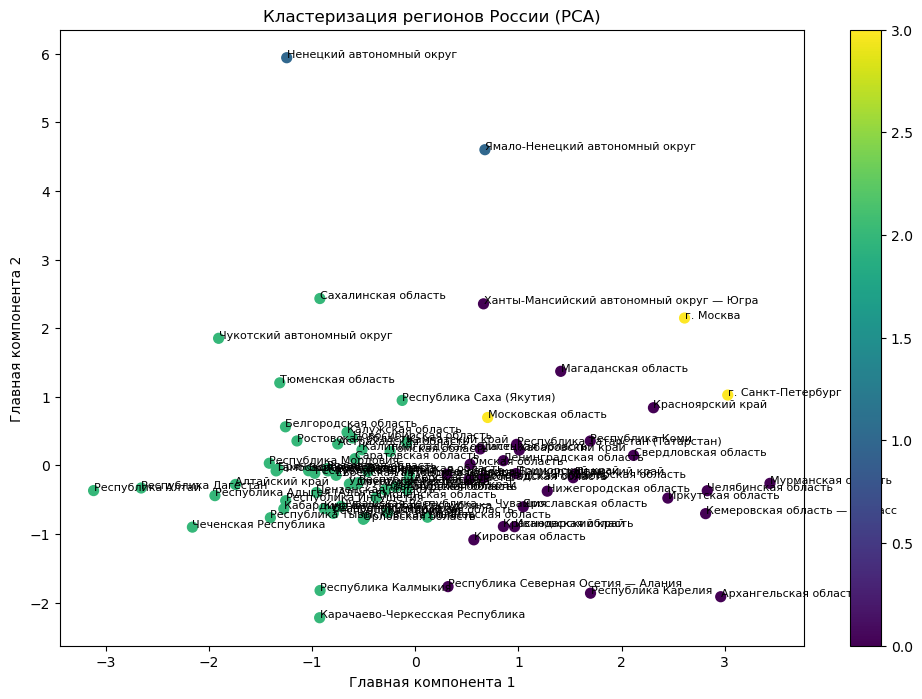

In [15]:
pca = PCA(n_components=2)# Упрощение 6 признаков до 2, чтобы нарисовать на плоскости
clust_pca = pca.fit_transform(clust_scaled_df)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(clust_pca[:, 0], clust_pca[:, 1], c=clusters, cmap='viridis', s=50)
plt.colorbar(scatter)
plt.title('Кластеризация регионов России (PCA)')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')

# Подписал регионы для наглядности
for i, region in enumerate(agg_df['Регион']):
    # if i % 5 == 0: 
        plt.annotate(region, (clust_pca[i, 0], clust_pca[i, 1]), fontsize=8)

### Вклад признаков в главные компоненты

In [16]:
components_df = pd.DataFrame(
    pca.components_.T,
    columns=['Компонента_1', 'Компонента_2'],
    index=features_clustering
)
components_df

,Компонента_1,Компонента_2
ВРП_на_душу_руб,0.042512,0.738031
Объем_сточных_вод_млн_м3,0.510562,0.056024
Доля_городского_населения_%,0.553955,0.308990
Индекс_промыш_производства_%,-0.339958,0.261402
Водоемкость_ВРП,0.401274,-0.512235
Инвестиционная_активность,0.392505,0.161187


### Профиль кластеров и состав групп

In [17]:
print(cluster_profile)

# Принадлежность региона к кластеру
for cluster_num in range(optimal_k):
    print(f"\n--- Кластер {cluster_num} ---")
    regions_in_cluster = agg_df[agg_df['Cluster'] == cluster_num]['Регион'].tolist()
    print(regions_in_cluster)

         ВРП_на_душу_руб  Объем_сточных_вод_млн_м3  \
Cluster                                              
0           4.040139e+05                315.044717   
1           4.315704e+06                 16.960417   
2           2.843568e+05                 68.655559   
3           6.404624e+05               1094.686389   

         Доля_городского_населения_%  Индекс_промыш_производства_%  \
Cluster                                                              
0                          76.951786                    103.468145   
1                          76.839583                    105.783542   
2                          64.009917                    105.747339   
3                          93.176389                    107.208472   

         Водоемкость_ВРП  Инвестиционная_активность  
Cluster                                              
0               0.000504                  12.507447  
1               0.000012                  10.592576  
2               0.000271              

### Кратковременный вывод
Модель разбила по такому принципу я предполагаю:

Кластер 0: «Крупные городские регионы с высоким уровнем урбанизации, большим ВРП и значительными экологическими нагрузками (стоки, использование воды, инвестиции в ООС).»​

Кластер 1: «Преимущественно сельские и менее обеспеченные регионы с невысоким ВРП и долей городского населения, но более выраженной ролью сельского хозяйства.»​

Кластер 2: «Регионы с развивающейся промышленностью и средним уровнем ВРП, для которых характерен заметный промышленный рост при относительно низкой доле инвестиций в охрану окружающей среды.»​

Кластер 3: «Ресурсно-ориентированные регионы с очень высоким ВРП и небольшой численностью населения, часто с относительно низкими объёмами стоков на душу населения.»

 

# Объеденение датасета с итогами кластеризации

In [18]:
# славарь с Регион -> Кластер
cluster_map = agg_df.set_index('Регион')['Cluster'].to_dict()

# Новый признак в df - Принадлежность к одному из кластеров
df['Cluster'] = df['Регион'].map(cluster_map)

df.head()

,Регион,Год,Объем_сточных_вод_млн_м3,Инвестиции_в_ООС_тыс_руб,ВРП_млн_руб,ВРП_на_душу_руб,Доля_городского_населения_%,Использование_свеж_воды_млн_м3,Индекс_промыш_производства_%,Cluster
0,Алтайский край,2000,31.0,176660.0,46736.8,17660.5,52.8,569.0,109.2,2
1,Алтайский край,2001,34.0,111590.0,61854.4,23509.0,53.1,599.0,109.4,2
2,Алтайский край,2002,36.0,67466.0,73107.4,27991.2,53.2,563.0,100.1,2
3,Алтайский край,2003,36.0,50114.0,88733.3,34295.8,53.5,516.0,105.5,2
4,Алтайский край,2004,36.0,38270.0,114840.5,44934.9,53.7,488.0,102.6,2


In [19]:
df.to_excel('../../data/raw/dataset_with_cluster.xlsx')
df.to_csv('../../data/raw/dataset_with_cluster.csv')